# ROMS-TOOLS setup for Iceland2_MARBL_2024

First step is to set up the outer grid using ROMS-TOOLS and save the grid file.

In [1]:
from roms_tools import Grid

/home/x-uheede/.conda/envs/romstools-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/'
datasets='/anvil/projects/x-ees250129/Datasets/'
model_name='Iceland2'
child_name='Iceland3'
grid_path='/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_grid.nc'

In [3]:
#%%time

#grid = Grid(
#    nx=512,
#    ny=512,
#    size_x=102.4,
#    size_y=102.4,
#    center_lon=-22.3,
#    center_lat=64.39,
#    rot=0,
#    mask_shapefile=datasets+"GSHHS/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp",
#    topography_source={
#        "name": "EMOD",
#        "path": datasets+"EMODnet_C2.nc"},
#    N=60  # number of vertical layers
#)

#grid.plot()

In [4]:
#import sys
#sys.path.append("/anvil/projects/x-ees250129/x-uheede/fill_narrows")

#import fill_narrow

## After grid creation, you can fill narrow passages
#grid.ds = fill_narrow.fill_narrow_passages(
#    grid.ds,
#    mask_var="mask_rho",
#    max_iterations=10,
#    )

#grid.plot()

In [5]:
grid = Grid.from_file(grid_path)
#grid.update_vertical_coordinate(N=60, theta_s=5.0, theta_b=2.0, hc=300.0, verbose=False)
#grid.plot()

In [6]:
filepath = project+model_name+'_grid.nc'

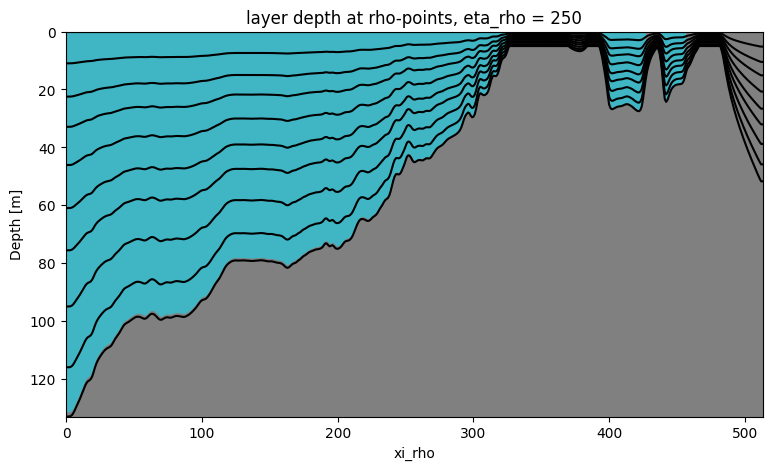

In [7]:
grid.plot_vertical_coordinate(eta=250, max_nr_layer_contours=10,)

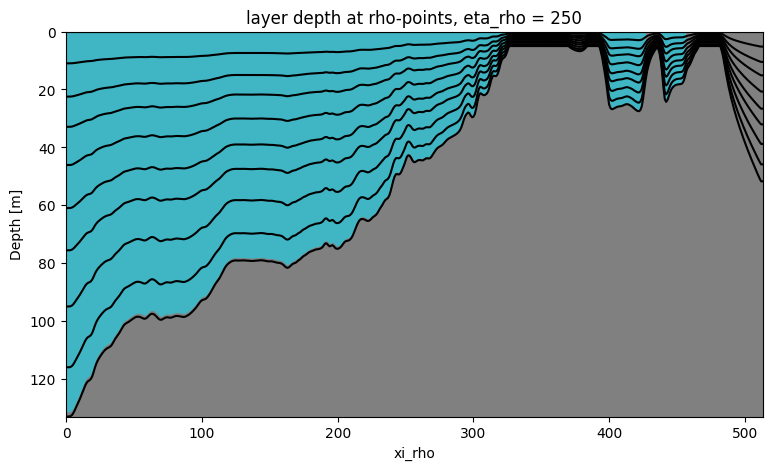

In [8]:
grid.plot_vertical_coordinate(eta=250, max_nr_layer_contours=10,)

In [9]:
#grid.save(filepath)

In [10]:
tpxo_path = datasets+"TPXO/TPXO10.v2/"
tpxo_dict = {
    "grid": tpxo_path + "grid_tpxo10v2.nc",
    "h": tpxo_path + "h_tpxo10.v2.nc",
    "u": tpxo_path + "u_tpxo10.v2.nc",
}

Next, we set up tidal forcing:

In [11]:
from roms_tools import TidalForcing

In [12]:
from datetime import datetime

In [13]:
model_reference_date = datetime(2000, 1, 1)

In [14]:

tidal_forcing = TidalForcing(
    grid=grid,
    source={"name": "TPXO", "path": tpxo_dict},
    ntides=15,  # Number of constituents to consider <= 15. Default is 10.
    model_reference_date=model_reference_date,  # Model reference date. Default is January 1, 2000.
    use_dask=True
)

In [15]:
filepath = project+model_name+"_tides.nc"

In [16]:
%time tidal_forcing.save(filepath)

2026-01-30 15:44:07 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_tides.nc


[########################################] | 100% Completed | 2.01 sms
CPU times: user 4.2 s, sys: 1.54 s, total: 5.74 s
Wall time: 2.12 s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_tides.nc')]

In [17]:
from roms_tools import Grid, InitialConditions

In [18]:
parent_grid = Grid.from_file('/anvil/projects/x-ees250129/x-uheede/MATLAB/setup_r2r_phys+bgc/1.Make_grid/Iceland1_grid_MAT1.nc')
parent_grid.update_vertical_coordinate(N=60, theta_s=5.0, theta_b=2.0, hc=300.0, verbose=False)
restart_date = datetime(2024, 2, 1, 0, 0, 0)
restart_file = project+"Iceland1_MARBL_2024_rst.20240201000000.nc"

2026-01-30 15:44:09 - WARNING - Vertical coordinates (Cs_r, Cs_w) not found in grid file.
2026-01-30 15:44:09 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 5.0, theta_b = 2.0, hc = 300.0 ===
2026-01-30 15:44:09 - INFO - Total time: 0.003 seconds
2026-01-30 15:44:09 - INFO - ================================================================================================


In [19]:
%%time


initial_conditions_from_roms = InitialConditions(
    grid=grid,
    ini_time=restart_date,
    source={"name": "ROMS", "grid": parent_grid, "path": restart_file},
    use_dask=True,
    bgc_source={
        "name": "ROMS",
        "grid": parent_grid,
        "path": restart_file,
    },
)


CPU times: user 21min 47s, sys: 3.72 s, total: 21min 51s
Wall time: 41.8 s


In [20]:
filepath = project+"Iceland2_initial_conditions_020240201.nc"
%time initial_conditions_from_roms.save(filepath)

2026-01-30 15:44:51 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_initial_conditions_020240201.nc


[#######################                 ] | 58% Completed | 34.01 ss

/home/x-uheede/.conda/envs/romstools-test/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


[########################################] | 100% Completed | 44.04 s
CPU times: user 58min 20s, sys: 20.9 s, total: 58min 41s
Wall time: 45.5 s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_initial_conditions_020240201.nc')]

In [21]:
%%time


initial_conditions_from_roms = InitialConditions(
    grid=grid,
    ini_time=restart_date,
    source={"name": "ROMS", "grid": parent_grid, "path": restart_file},
    use_dask=True,
    bgc_source={
        "name": "ROMS",
        "grid": parent_grid,
        "path": restart_file,
    },
)

CPU times: user 45min 23s, sys: 3.36 s, total: 45min 27s
Wall time: 50.1 s


For the surface forcing, we use ERA5 plus the unified BGC dataset

In [22]:
from roms_tools import Grid, SurfaceForcing

In [23]:
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 12, 31)

In [24]:
surface_forcing_kwargs = {
    "grid": grid,
    "start_time": start_time,
    "end_time": end_time,
    "type": "physics",
    "model_reference_date": datetime(2000, 1, 1), # this is the default
}

In [25]:
%%time

surface_forcing = SurfaceForcing(
    **surface_forcing_kwargs,
    source={"name": "ERA5"},
    use_dask=True,
)

2026-01-30 15:46:27 - INFO - No path specified for ERA5 source; defaulting to ARCO ERA5 dataset on Google Cloud.
2026-01-30 15:48:45 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.


CPU times: user 17min 19s, sys: 2min 48s, total: 20min 7s
Wall time: 14min 23s


[########################################] | 100% Completed | 303.43 ms


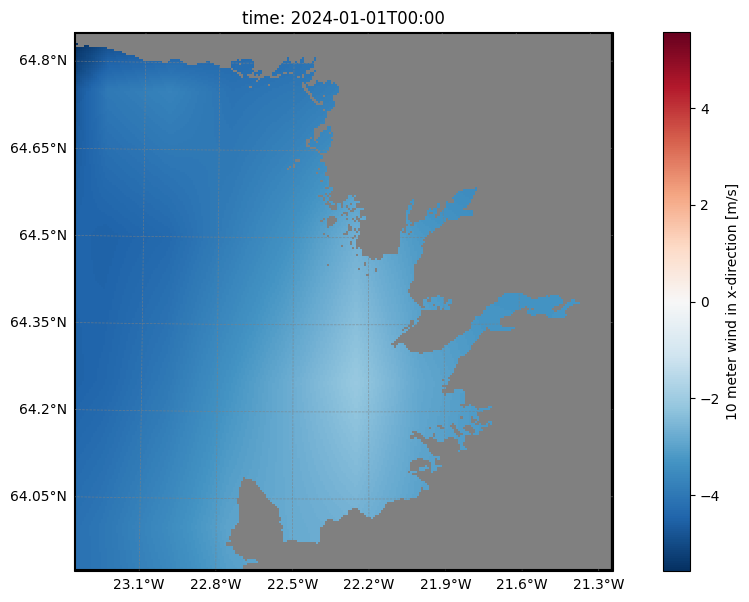

In [26]:
surface_forcing.plot("uwnd", time=0)

In [27]:
#cesm_bgc_path = "/global/cfs/projectdirs/m4746/Datasets/CESM_REGRIDDED/CESM-surface_lowres_regridded.nc"
unified_bgc_path = datasets+"UNIFIED/BGCdataset.nc"

In [28]:
%%time

unified_bgc_surface_forcing = SurfaceForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    source={"name": "UNIFIED", "path": unified_bgc_path, "climatology": True},
    type="bgc",
    use_dask=True,
)

2026-01-30 16:00:54 - WARNING - Optional variables missing (but not critical): ['pco2_air_alt']
2026-01-30 16:00:54 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.


CPU times: user 149 ms, sys: 10.7 ms, total: 160 ms
Wall time: 263 ms


In [29]:
filepath = project+model_name+"_surface_forcing2024.nc"

In [30]:
%time surface_forcing.save(filepath, group=True)

2026-01-30 16:00:59 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202401.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202402.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202403.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202404.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202405.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202406.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202407.nc
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202408.nc
/anvil/

[########################################] | 100% Completed | 98.64 s
[########################################] | 100% Completed | 92.72 s
[########################################] | 100% Completed | 97.28 s
[########################################] | 100% Completed | 95.96 s
[########################################] | 100% Completed | 95.82 s
[########################################] | 100% Completed | 91.95 s
[########################################] | 100% Completed | 97.19 s
[########################################] | 100% Completed | 93.93 s
[########################################] | 100% Completed | 92.53 s
[########################################] | 100% Completed | 94.22 s
[########################################] | 100% Completed | 91.62 s
[########################################] | 100% Completed | 90.41 s
CPU times: user 27min 15s, sys: 5min 6s, total: 32min 22s
Wall time: 21min 58s


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202401.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202402.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202403.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202404.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202405.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202406.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_surface_forcing2024_202407.nc'),
 PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT

In [31]:
filepath = project+model_name+"_bgc_surface_forcing.nc"

In [32]:
%time unified_bgc_surface_forcing.save(filepath)

2026-01-30 16:22:52 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_bgc_surface_forcing_clim.nc


[########################################] | 100% Completed | 303.39 ms
CPU times: user 187 ms, sys: 19.2 ms, total: 207 ms
Wall time: 381 ms


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_bgc_surface_forcing_clim.nc')]

Next we generate the initial file

In [33]:
from roms_tools import Grid, ChildGrid

In [34]:
parent_grid = grid

In [35]:
child_grid_parameters = {
    "nx": 642,
    "ny": 386,
    "size_x": 32,
    "size_y": 19.2,
    "center_lon": -21.68,
    "center_lat": 64.32,
    "rot": 0,
    "topography_source": {
        "name": "EMOD",
        "path": datasets+"EMODnet_C2.nc"},
    "N":40  # number of vertical layers
}

In [36]:
child_grid = ChildGrid(
    **child_grid_parameters,
    parent_grid=parent_grid,
    boundaries={
        "south": True,
        "east": False,
        "north": False,
        "west": True,
    },  # this is the default
    metadata={"prefix": "child", "period": 1800.0}  # this is the default
)

2026-01-30 16:22:54 - INFO - Using boundary configuration: {'south': True, 'east': False, 'north': False, 'west': True}


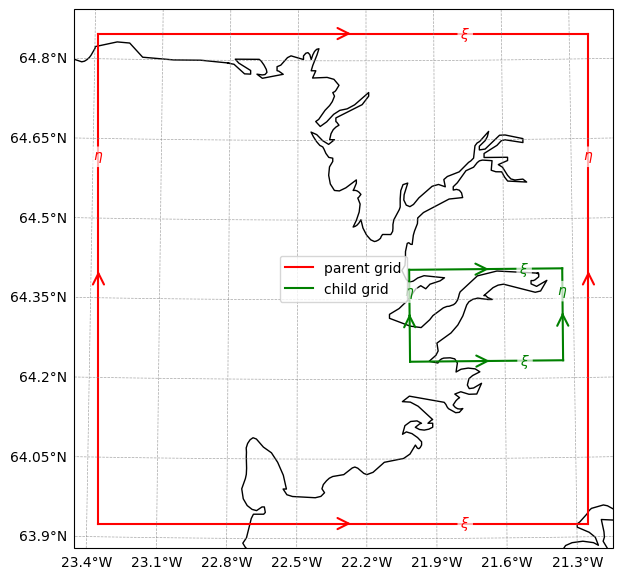

In [37]:
child_grid.plot_nesting(with_dim_names=True)

In [38]:
filepath = project+child_name+"_grid.nc"
child_grid.save(filepath=filepath)

2026-01-30 16:24:05 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_grid.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_grid.nc')]

In [39]:
filepath_nesting = project+child_name+"_edata.nc"

In [40]:
child_grid.save_nesting(filepath=filepath_nesting)

2026-01-30 16:24:05 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_edata.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland3_edata.nc')]

In [41]:
import xarray as xr

In [42]:
from roms_tools import RiverForcing, Grid

In [43]:
from datetime import datetime

In [44]:
riv0=xr.open_dataset('/anvil/projects/x-ees250129/Datasets/Iceland_river_dataset/Hvalfjordur_rivers_2023.nc')

In [45]:
riv0['time']=[202401., 202402., 202403., 202404., 202405., 202406., 202407., 202408.,
       202409., 202410., 202411., 202412.]

In [46]:
riv0.to_netcdf('/anvil/projects/x-ees250129/Datasets/Iceland_river_dataset/Hvalfjordur_rivers_2024.nc')

In [47]:
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 12, 31)

In [48]:
river_forcing = RiverForcing(
    grid=grid,
    start_time=start_time,
    end_time=end_time,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    include_bgc=True,
    source = {
    "name": "DAI",
    "path": "/anvil/projects/x-ees250129/Datasets/Iceland_river_dataset/Hvalfjordur_rivers_2024.nc",
    "climatology": False
}
    
)

2026-01-30 16:24:05 - INFO - No river indices provided. Identify all rivers within the ROMS domain and assign each of them to the nearest coastal point.
2026-01-30 16:24:05 - WARNING - No records found at or before the start_time: 2024-01-01 00:00:00.
2026-01-30 16:24:05 - WARNING - No records found at or after the end_time: 2024-12-31 00:00:00.
2026-01-30 16:24:05 - INFO - Creating 2 synthetic river(s) to handle overlapping entries.


In [49]:
river_forcing.ds

<xarray.Dataset> Size: 2MB
Dimensions:           (nriver: 16, river_time: 12, ntracers: 34, eta_rho: 514,
                       xi_rho: 514)
Coordinates:
    river_name        (nriver) object 128B 'HVAL1' 'HVAL2' ... 'overlap_2'
  * nriver            (nriver) int64 128B 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    abs_time          (river_time) datetime64[ns] 96B 2024-01-15 ... 2024-12-15
  * river_time        (river_time) float64 96B 8.78e+03 8.811e+03 ... 9.115e+03
    tracer_name       (ntracers) <U11 1kB 'temp' 'salt' ... 'diazP' 'diazFe'
    tracer_unit       (ntracers) <U15 2kB 'degrees Celsius' 'PSU' ... 'mmol/m^3'
    tracer_long_name  (ntracers) <U43 6kB 'potential temperature' ... 'diazot...
Dimensions without coordinates: ntracers, eta_rho, xi_rho
Data variables:
    river_volume      (river_time, nriver) float64 2kB 0.09365 0.1489 ... 1.691
    river_tracer      (river_time, ntracers, nriver) float64 52kB 17.0 ... 1....
    river_index       (eta_rho, xi_rho) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    river_fraction    (eta_rho, xi_rho) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

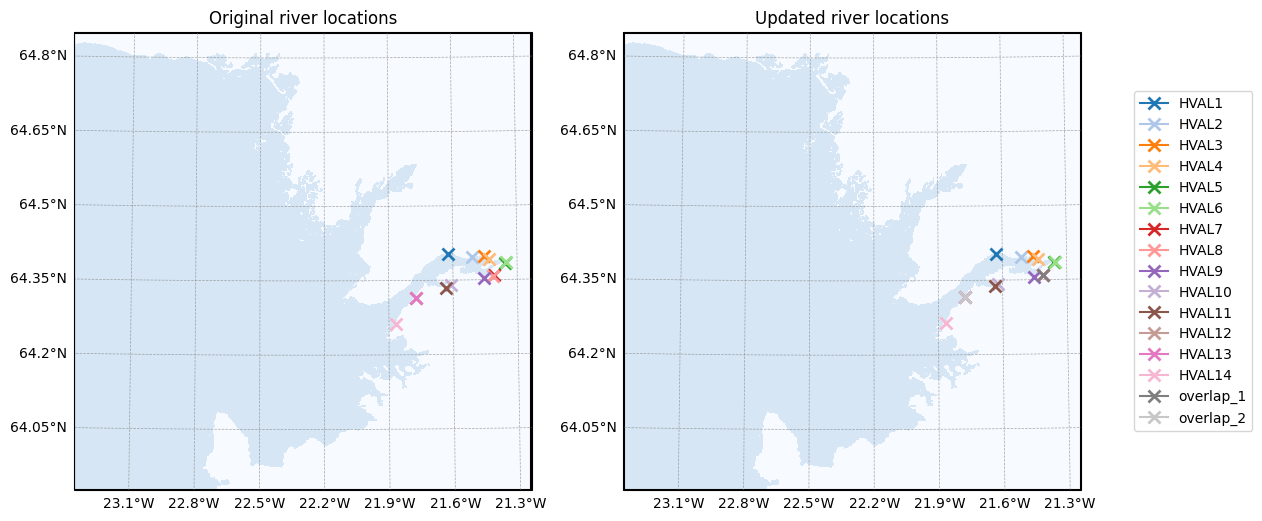

In [50]:
river_forcing.plot_locations()

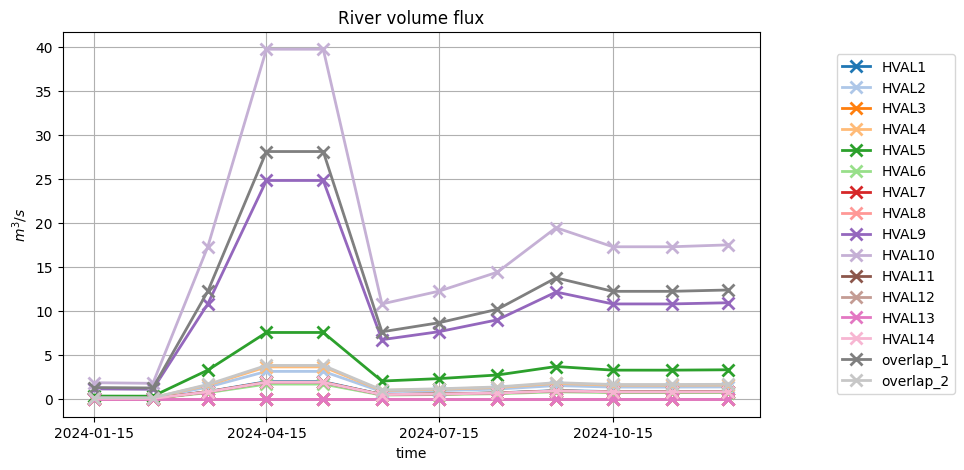

In [51]:
river_forcing.plot("river_volume")

In [52]:
filepath = project+model_name+"_rivers.nc"

In [53]:
river_forcing.save(filepath=filepath)

2026-01-30 16:24:07 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_rivers.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/Iceland2_rivers.nc')]

Making some customizations to the river forcing (we have observed values of alk and DIC in the rivers and we also know the water is not going to be 17 degrees warm!). We add nutrients (observed values in fjord before spring bloom) and we add observed riverine values of Alk and DIC. These should be subject to change.

In [54]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
riv=xr.open_dataset(filepath)
riv.load()

/tmp/ipykernel_3193883/3130065273.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  riv=xr.open_dataset(filepath)


<xarray.Dataset> Size: 2MB
Dimensions:           (river_time: 12, nriver: 16, ntracers: 34, eta_rho: 514,
                       xi_rho: 514)
Coordinates:
    river_name        (nriver) object 128B 'HVAL1' 'HVAL2' ... 'overlap_2'
  * nriver            (nriver) int32 64B 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    abs_time          (river_time) datetime64[ns] 96B 2024-01-15 ... 2024-12-15
  * river_time        (river_time) timedelta64[ns] 96B 8780 days ... 9115 days
    tracer_name       (ntracers) object 272B 'temp' 'salt' ... 'diazP' 'diazFe'
    tracer_unit       (ntracers) object 272B 'degrees Celsius' ... 'mmol/m^3'
    tracer_long_name  (ntracers) object 272B 'potential temperature' ... 'dia...
Dimensions without coordinates: ntracers, eta_rho, xi_rho
Data variables:
    river_volume      (river_time, nriver) float64 2kB 0.09365 0.1489 ... 1.691
    river_tracer      (river_time, ntracers, nriver) float64 52kB 17.0 ... 1....
    river_index       (eta_rho, xi_rho) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    river_fraction    (eta_rho, xi_rho) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [55]:
# Create new array
new_tracer = np.zeros_like(riv['river_tracer'].values)

# Temperature varies sinusoidally with time
temp = 10 * np.sin(np.linspace(0, np.pi, riv.dims['river_time']))  # 12-month cycle

# Loop through tracers
for i, tracer in enumerate(riv['tracer_name'].values):
    if tracer == 'temp':
        new_tracer[:, i, :] = temp[:, np.newaxis]  # vary with time
    elif tracer == 'salt':
        new_tracer[:, i, :] = 1
    elif tracer == 'PO4':
        new_tracer[:, i, :] = 0.4
    elif tracer == 'NO3':
        new_tracer[:, i, :] = 6
    elif tracer == 'SiO3':
        new_tracer[:, i, :] = 3
    elif tracer == 'NH4':
        new_tracer[:, i, :] = 0.4
    elif tracer == 'Fe':
        new_tracer[:, i, :] = 0.000197
    elif tracer == 'Lig':
        new_tracer[:, i, :] = 0.000465    
    elif tracer == 'O2':
        new_tracer[:, i, :] = 360    
    elif tracer == 'DIC':
        new_tracer[:, i, :] = 313    
    elif tracer == 'DIC_ALT_CO2':
        new_tracer[:, i, :] = 313  
    elif tracer == 'ALK':
        new_tracer[:, i, :] = 282 
    elif tracer == 'ALK_ALT_CO2':
        new_tracer[:, i, :] = 282 
    else:
        new_tracer[:, i, :] = 0.0
riv['river_tracer'] = (riv['river_tracer'].dims, new_tracer)

/tmp/ipykernel_3193883/608848569.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  temp = 10 * np.sin(np.linspace(0, np.pi, riv.dims['river_time']))  # 12-month cycle


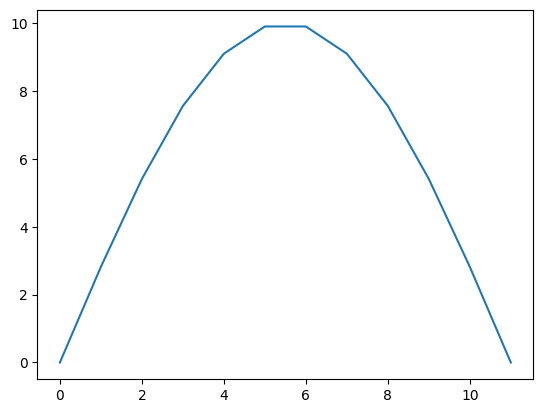

In [56]:
plt.plot(temp)

In [57]:
riv.to_netcdf(project+model_name+"_rivers_modified.nc")

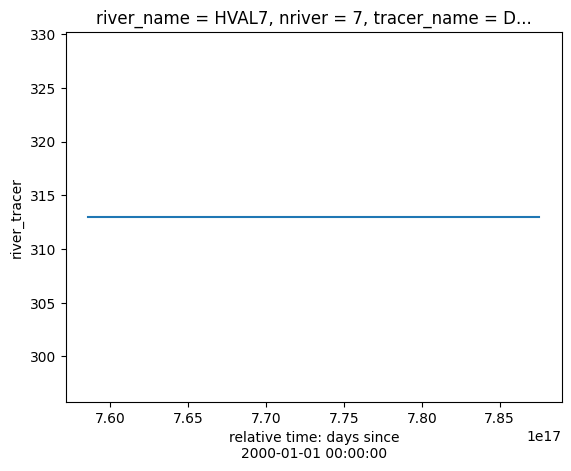

In [58]:
import xarray as xr

# Open your modified file
river = xr.open_dataset(project+model_name+"_rivers_modified.nc")
river.load()
# Show what tracers exist
river['river_tracer'].isel(ntracers=10).isel(nriver=6).plot()



Now, we make another river forcing file with half as much volume

In [59]:
riv['river_volume'][:] = riv['river_volume'].isel(river_time=7)*0.6

In [60]:
winter_months = [1, 2, 3, 4, 11, 12]

# Create a boolean mask for winter times
winter_mask = riv['abs_time'].dt.month.isin(winter_months)

# Set river_volume to zero where the mask is True
riv['river_volume'] = riv['river_volume'].where(~winter_mask, 0.0)

In [61]:
riv

<xarray.Dataset> Size: 2MB
Dimensions:           (river_time: 12, nriver: 16, ntracers: 34, eta_rho: 514,
                       xi_rho: 514)
Coordinates:
    river_name        (nriver) object 128B 'HVAL1' 'HVAL2' ... 'overlap_2'
  * nriver            (nriver) int32 64B 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    abs_time          (river_time) datetime64[ns] 96B 2024-01-15 ... 2024-12-15
  * river_time        (river_time) timedelta64[ns] 96B 8780 days ... 9115 days
    tracer_name       (ntracers) object 272B 'temp' 'salt' ... 'diazP' 'diazFe'
    tracer_unit       (ntracers) object 272B 'degrees Celsius' ... 'mmol/m^3'
    tracer_long_name  (ntracers) object 272B 'potential temperature' ... 'dia...
Dimensions without coordinates: ntracers, eta_rho, xi_rho
Data variables:
    river_volume      (river_time, nriver) float64 2kB 0.0 0.0 0.0 ... 0.0 0.0
    river_tracer      (river_time, ntracers, nriver) float64 52kB 0.0 ... 0.0
    river_index       (eta_rho, xi_rho) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    river_fraction    (eta_rho, xi_rho) float32 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [62]:
riv.to_netcdf(project+model_name+"_rivers_modified_new40off.nc")

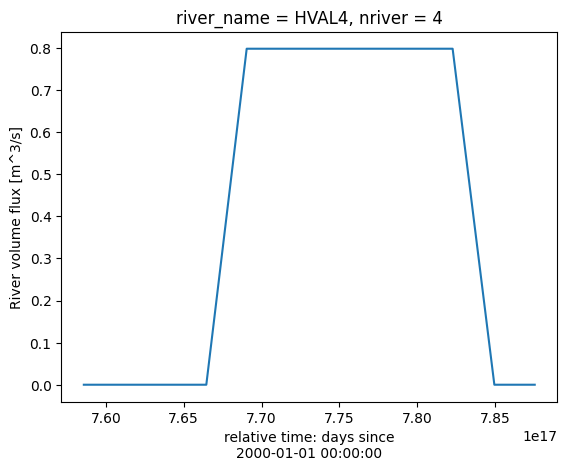

In [63]:
import xarray as xr

# Open your modified file
river1 = xr.open_dataset(project+model_name+"_rivers_modified_new40off.nc")
river1.load()
# Show what tracers exist
river1['river_volume'].isel(nriver=3).plot()


In [64]:
river1['river_volume'].isel(nriver=6)

<xarray.DataArray 'river_volume' (river_time: 12)> Size: 96B
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Coordinates:
    river_name  object 8B 'HVAL7'
    nriver      int32 4B 7
    abs_time    (river_time) datetime64[ns] 96B 2024-01-15 ... 2024-12-15
  * river_time  (river_time) timedelta64[ns] 96B 8780 days ... 9115 days
Attributes:
    long_name:  River volume flux
    units:      m^3/s